![image.png](https://i.imgur.com/a3uAqnb.png)

## Pre-trained CNN with VGG for Image Classification

This exercise demonstrates how to use a pre-trained VGG model for image classification on the CIFAR-10 dataset using PyTorch. We will leverage transfer learning by modifying the final layers of the VGG network to classify images into 10 categories.

### Dependencies

First, let's install and import the necessary libraries.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1️⃣ Dataset Class

We'll use `torchvision.datasets.CIFAR10` directly, as it's a standard dataset with built-in functionalities. We'll define transformations for data augmentation and normalization, and then create `DataLoader` instances for training and testing.

In [ ]:
# TODO: Define transformations for training and test sets
# Task: Create data augmentation pipeline for training and normalization for both
# HINT: Normalize values for CIFAR-10: mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)

# Training transformations (should include RandomCrop, RandomHorizontalFlip, ToTensor, Normalize)
transform_train = transforms.Compose([
    # YOUR CODE HERE
])

# Test transformations (should include ToTensor, Normalize)
transform_test = transforms.Compose([
    # YOUR CODE HERE
])


trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# TODO: Create DataLoaders
trainloader = None  # YOUR CODE HERE
testloader = None   # YOUR CODE HERE

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Number of training samples: {len(trainset)}")
print(f"Number of test samples: {len(testset)}")

#### Let's display some images

It's always good practice to visualize some of the data to ensure it's loaded correctly.

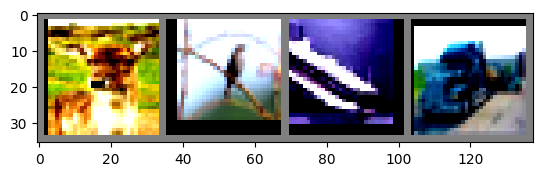

deer  bird  ship  truck


In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images[:4]))
# Print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

### 2️⃣ Model Class

We will use a pre-trained VGG-16 model from `torchvision.models`. We'll freeze the feature extraction layers and replace the classifier head to adapt it for CIFAR-10's 10 classes.

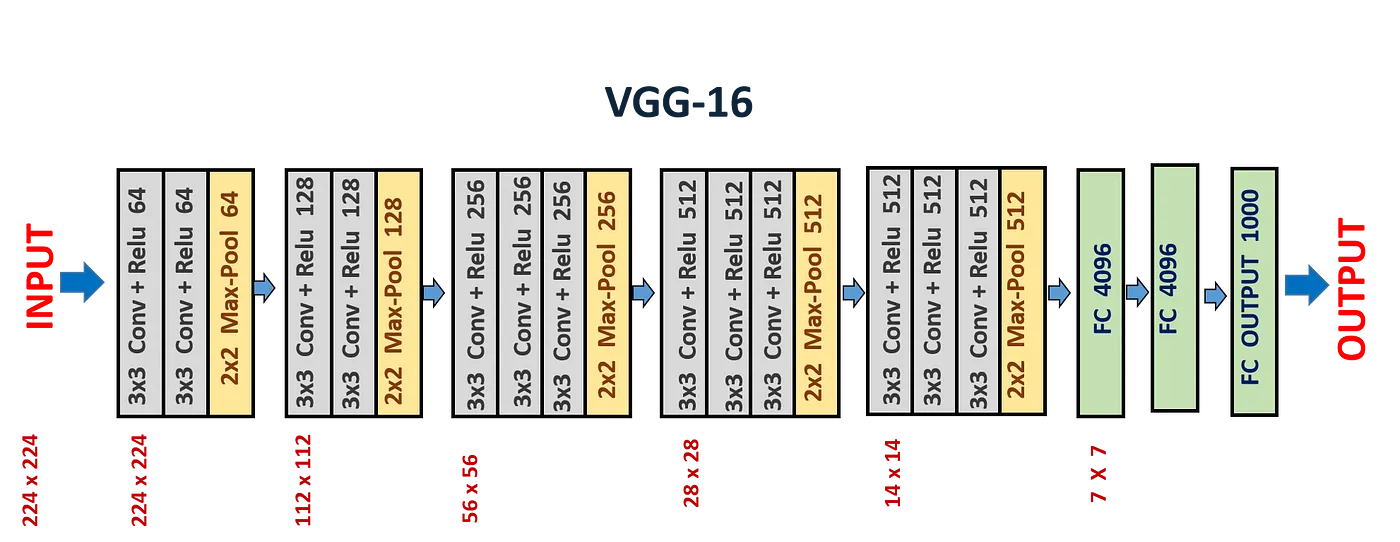

### Convolution Operation
The convolution layer applies a kernel/filter over the input image or feature map:

$$
Y(i, j, k) = \sum_{c=1}^{C_\text{in}} \sum_{m=1}^{M} \sum_{n=1}^{N} X(i+m-1, j+n-1, c) \cdot K(m, n, c, k)
$$

- \(X\) = input feature map (H × W × C_in)  
- \(K\) = kernel/filter (M × N × C_in × C_out)  
- \(Y\) = output feature map (H' × W' × C_out)


### Weight Freezing Concept
For a pre-trained network:

$$
\theta_\text{frozen} \gets \theta_\text{pretrained} \quad \text{(no updates during training)}
$$

Only the **classifier weights** are updated:

$$
\theta_\text{trainable} \gets \theta_\text{new} \quad \text{(updated via backpropagation)}
$$


In [ ]:
# TODO: Define the VGG16_CIFAR10 model class
# Task: Create a custom neural network class that:
# 1. Loads a pre-trained VGG16 model
# 2. Freezes the feature extraction layers (so they won't be trained)
# 3. Replaces the classifier with a new one suitable for CIFAR-10's 10 classes

# Hint: Use models.vgg16(weights=models.VGG16_Weights.DEFAULT) to load the pretrained model
# Then freeze the feature extractor parameters and replace the classifier for CIFAR-10 (10 classes)
# For VGG16 on 32x32, it's typically 512 (after features and AdaptiveAvgPool2d)
# The classifier should include an AdaptiveAvgPool2d and a customized fully connected network

class VGG16_CIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16_CIFAR10, self).__init__()
        # YOUR CODE HERE
        # Load pre-trained VGG16 model
        
        # Freeze all parameters in the feature extractor
        
        # Store the features
        
        # Replace the classifier with a new one for CIFAR-10
        # Assuming features output 512x1x1 for 32x32 input
        
        # Include an AdaptiveAvgPool2d layer to handle different input sizes
        # To handle potential variations in feature map size, we can use AdaptiveAvgPool2d
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        pass

    def forward(self, x):
        # YOUR CODE HERE
        # Pass through features, pool, flatten, and classifier
        pass

# Instantiate the model and move to device
model = VGG16_CIFAR10(num_classes=10).to(device)
print(model)

### 3️⃣ Training and Validation Loops

We will define functions for a single training epoch and a single validation epoch. The training loop involves forward pass, loss calculation, backward pass, and optimizer step. The validation loop only performs a forward pass and loss calculation to evaluate performance on unseen data.

In [ ]:
# TODO: Define the loss function and optimizer
# Task: Use CrossEntropyLoss and SGD optimizer (train only the classifier parameters)

# Hint: For training: set model.train(), loop through batches, zero gradients, 
# forward pass, calculate loss, backward pass, optimizer step
# For validation: set model.eval(), use torch.no_grad(), no gradient updates

criterion = None  # YOUR CODE HERE
optimizer = None  # YOUR CODE HERE

# TODO: Implement the training epoch function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # YOUR CODE HERE
    # Loop through the dataloader, perform forward pass, calculate loss,
    # backward pass, and optimizer step
    
    pass

    return running_loss / len(dataloader), correct_predictions / total_samples

# TODO: Implement the validation epoch function
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # YOUR CODE HERE
    # Remember to use torch.no_grad() context manager
    
    pass

    return running_loss / len(dataloader), correct_predictions / total_samples

### 4️⃣ Running Training

Now, let's train our model for a few epochs and record the training and validation loss and accuracy. We'll then plot these metrics to observe the model's learning progress.

In [ ]:
# TODO: Implement the training loop
# Task: Train the model for 5 epochs and track losses and accuracies

num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Starting Training...")

# YOUR CODE HERE
# Loop through epochs, call train_epoch and validate_epoch functions
# Append results to the lists and print progress

#### Plot loss and some predictions

Let's visualize the training and validation loss and accuracy over epochs.

In [ ]:
# TODO: Plot the training curves
# Task: Create two subplots showing loss and accuracy over epochs

plt.figure(figsize=(12, 5))

# YOUR CODE HERE
# Subplot 1: Plot training and validation loss
# Subplot 2: Plot training and validation accuracy

plt.tight_layout()
plt.show()

### 4️⃣ Model Evaluation and Predictions

Finally, let's evaluate the model on the test set and see some predictions.

In [ ]:
test_loss, test_acc = validate_epoch(model, testloader, criterion, device)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

Test Loss: 1.1345, Test Accuracy: 0.5929


#### Plot some predictions

Let's get a batch of images from the test set and display them along with their predicted and true labels.

In [ ]:
# TODO: Implement the prediction visualization function
# Task: Create a function that displays images with their predicted and actual labels

def plot_predictions(model, dataloader, classes, device, num_images=5):
    model.eval()
    fig = plt.figure(figsize=(10, 8))
    
    # YOUR CODE HERE
    # Loop through dataloader, get predictions, display images with labels
    
    pass

# Call the function to display predictions
plot_predictions(model, testloader, classes, device, num_images=5)

# Contributed By: Mohammed Bremoo